In [11]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.nuts import nuts
from algorithms.hmc import multi_chain_hmc
from utilities.helpers import effective_sample_size,autocorr_new

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())



[CpuDevice(id=0)]


In [12]:
beta_true = jnp.log(0.3)
gamma_true = jnp.log(0.1)

t_vec = jnp.linspace(0,100,100)

def rhs(t,state,args):
    S,I,R = state
    N = S + I + R

    beta,gamma = args

    beta = jnp.exp(beta)
    gamma = jnp.exp(gamma)

    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

In [13]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Euler(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [14]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
full_state = jnp.maximum(model(t_vec,jnp.array([100.,1.0,0.0]),(beta_true,gamma_true)),1e-6)

observations = jax.random.poisson(noise_key,full_state[:,1])


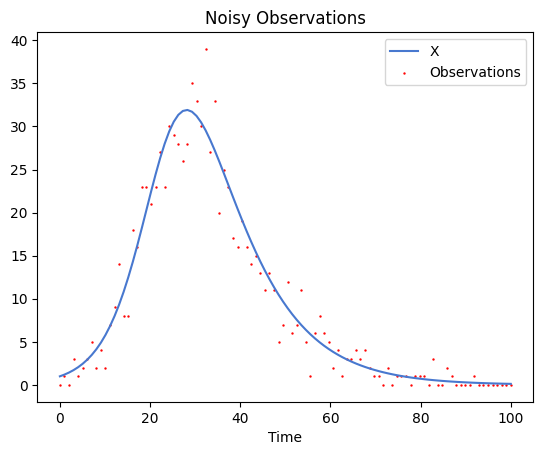

In [15]:
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,1],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [16]:
def log_likelihood(par):
    beta, gamma = par
    model_output = jnp.maximum(
        model(t_vec, jnp.array([100.0, 1.0, 0.0]), (beta, gamma)), 1e-6
    )
    return jnp.sum(
        jax.scipy.stats.poisson.logpmf(
            observations,
            model_output[:, 1],
        )
    )


def prior(par):
    beta, gamma = par
    return jax.scipy.stats.norm.logpdf(beta, 0.0, 1.0) + jax.scipy.stats.norm.logpdf(
        gamma, 0.0, 1.0
    )


def joint(par):
    return (log_likelihood(par) + prior(par))

In [17]:
func = jax.jit(jax.value_and_grad(joint))

D = 2
M = 100_000
Madapt = 1000
num_chains = 1
key = jax.random.key(0)
init_key, key = jax.random.split(key)

theta0 = jax.random.multivariate_normal(
    init_key,
    mean=jnp.log(jnp.array([0.1,0.1])),
    cov=0.1*jnp.eye(D),
    shape=(num_chains,),
)

nuts_key, key = jax.random.split(key)
t0 = perf_counter()
samples, lnprob = nuts(
    func,
    M,
    Madapt,
    jnp.log(jnp.array([0.1,0.1])),
    key=nuts_key,
    epsilon=0.01,
    num_chains=num_chains,
)
t1 = perf_counter()
print(f"Done. runtime {t1 - t0} seconds")
print(f"Effective sample size: {effective_sample_size(samples)}")
print(f"Integrated autocorrelation: {autocorr_new(samples)}")

KeyboardInterrupt: 

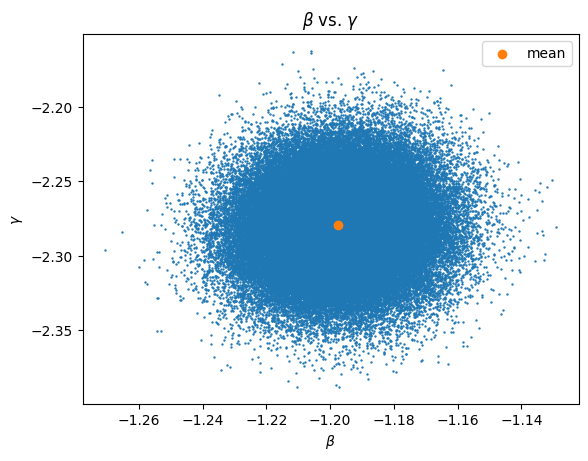

In [ ]:
plt.title('$\\beta$ vs. $\\gamma$')
plt.xlabel('$\\beta$')
plt.ylabel("$\\gamma$")

plt.scatter(samples[:,:,0],samples[:,:,1],s = 0.5)

mean = jnp.mean(samples[0,:],axis = 0)
plt.scatter(mean[0],mean[1],label = 'mean')
plt.legend()
plt.show()

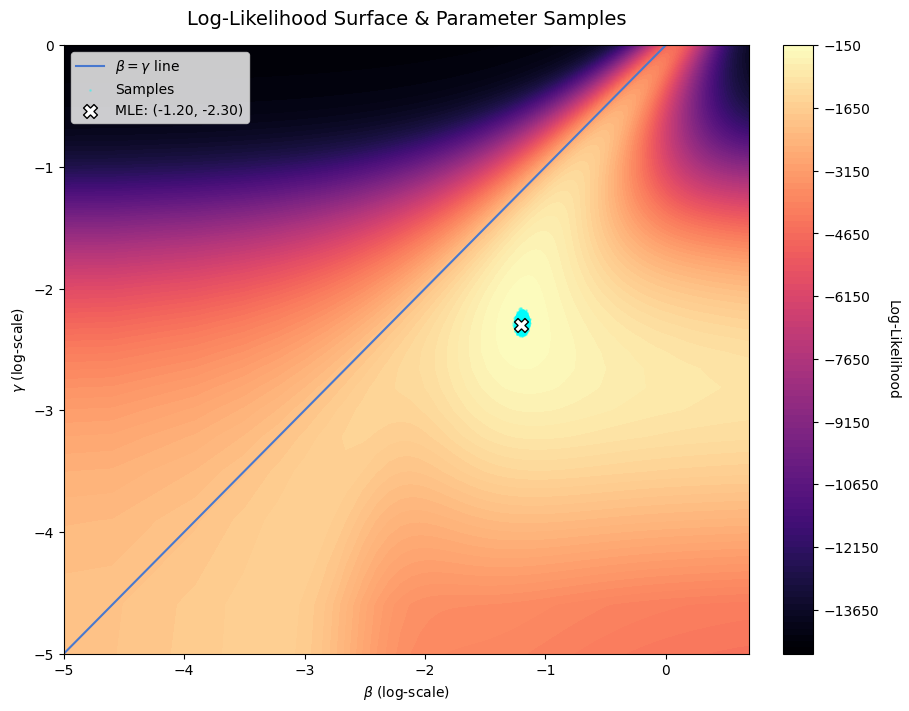

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import vmap

grid_range = jnp.arange(0.0001, 2.0, 0.01)
betas = jnp.log(grid_range)
gammas = jnp.log(grid_range)


def evaluate_joint(b, g):
    return joint(jnp.array([b, g]))

v_joint = vmap(vmap(evaluate_joint, in_axes=(None, 0)), in_axes=(0, None))
LL = v_joint(betas, gammas)

idx = jnp.argmax(LL)
i, j = jnp.unravel_index(idx, LL.shape)
beta_star, gamma_star = betas[i], gammas[j]


plt.style.use('seaborn-v0_8-muted') # Optional: cleaner styling
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

ax.set_ylim(-5,0.)
ax.set_xlim(-5,0.69)

X, Y = jnp.meshgrid(betas, gammas)


cp = ax.contourf(X, Y, LL.T, levels=100, cmap="magma")
cbar = fig.colorbar(cp, ax=ax)
cbar.set_label("Log-Likelihood", rotation=270, labelpad=15)

ax.plot(betas,betas, label = "$\\beta = \\gamma$ line")

ax.scatter(samples[...,0], samples[...,1], s=1, color="cyan", alpha=0.3, label="Samples")

ax.scatter(beta_star, gamma_star, marker="X", s=100, color="white", 
           edgecolor="black", label=f"MLE: ({beta_star:.2f}, {gamma_star:.2f})", zorder=10)


ax.set_xlabel(r"$\beta$ (log-scale)")
ax.set_ylabel(r"$\gamma$ (log-scale)")
ax.set_title("Log-Likelihood Surface & Parameter Samples", fontsize=14, pad=15)
ax.legend(frameon=True, facecolor='white')

plt.show()